# Span

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V02 — "Span" (DeepLearning.AI).*

Can something fail to be a basis of the plane yet still be a basis of *some* space? To answer that we need **span**. This lecture develops span, refines what a basis really is, and introduces **linear independence**. We cover:

- **Span**: everything reachable by linear combinations of a set of vectors.
- **Basis = minimal spanning set**, and why **dimension = size of a basis**.
- **Linear independence vs. dependence**, and how to test for it.
- The formal definition: a basis **spans** the space **and** is **linearly independent**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. What is the span?

The **span** of a set of vectors is the set of **all points reachable** by walking along those vectors in any linear combination.

- Two vectors in **different directions** span the **whole plane**.
- Two **collinear** vectors (same line — same *or* opposite direction) span only **that line**.
- A **single** vector spans the **line** through it and the origin.

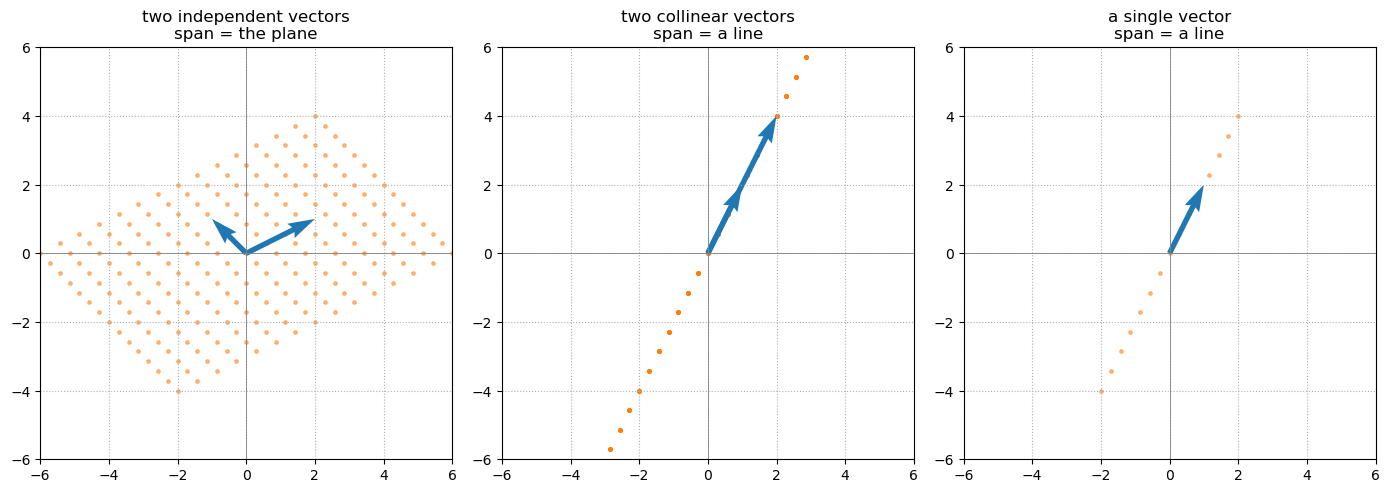

In [2]:
# Sample many linear combinations to 'see' the span
def span_points(vectors, lo=-2, hi=2, n=15):
    coeffs = np.linspace(lo, hi, n)
    pts = []
    if len(vectors) == 1:
        for a in coeffs:
            pts.append(a * vectors[0])
    else:
        for a in coeffs:
            for b in coeffs:
                pts.append(a * vectors[0] + b * vectors[1])
    return np.array(pts)

plane = [np.array([2, 1]), np.array([-1, 1])]   # independent -> plane
line2 = [np.array([1, 2]), np.array([2, 4])]    # collinear   -> line
one   = [np.array([1, 2])]                       # single vec -> line

fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))
for ax, vs, ttl in [(axes[0], plane, 'two independent vectors\nspan = the plane'),
                    (axes[1], line2, 'two collinear vectors\nspan = a line'),
                    (axes[2], one, 'a single vector\nspan = a line')]:
    P = span_points(vs)
    ax.scatter(P[:, 0], P[:, 1], s=6, color='C1', alpha=0.5)
    for v in vs:
        ax.quiver(0, 0, *v, angles='xy', scale_units='xy', scale=1, color='C0', width=0.013)
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_title(ttl)
    ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
plt.tight_layout(); plt.show()

## 2. A basis is a *minimal* spanning set

Two collinear vectors **span** a line — but they are **not a basis** of it, because they're *one too many*: either vector alone already spans the line. A **basis** is a **minimal spanning set**.

The same happens in the plane: **three** vectors can span the plane (a *spanning set*), but any one is **redundant**, so they're not a basis. Any two of them that aren't collinear form a basis.

**Dimension = the size of a basis:** a line has bases of length $1$ (dimension $1$), the plane has bases of length $2$ (dimension $2$). Every basis of a given space has the **same number** of vectors.

## 3. Linear independence vs. dependence

A set of vectors is **linearly independent** if **none** of them can be written as a linear combination of the others; otherwise it is **linearly dependent**.

- One vector alone: always independent.
- Two vectors in different directions: independent.
- Add a vector that's a **multiple** of another (or, more subtly, a combination of the others): now **dependent** — and the **span doesn't grow**. A span that fails to grow when you add a vector is the giveaway of dependence.

**Key fact:** if you have **more vectors than the dimension** of the space, the set is **always** linearly dependent (e.g. $\geq 3$ vectors in the plane, $\geq 4$ in 3D).

In [3]:
# Independence test via matrix rank: independent iff rank == number of vectors
def independent(*vectors):
    M = np.column_stack(vectors)
    return np.linalg.matrix_rank(M) == len(vectors)

print('{(2,1),(-1,1)} independent? ', independent(np.array([2, 1]), np.array([-1, 1])))
print('{(1,2),(2,4)}  independent? ', independent(np.array([1, 2]), np.array([2, 4])), ' (multiples)')
print('3 vectors in the plane independent?',
      independent(np.array([-1, 1]), np.array([2, 1]), np.array([-5, 3])), ' (too many)')

{(2,1),(-1,1)} independent?  True
{(1,2),(2,4)}  independent?  False  (multiples)
3 vectors in the plane independent? False  (too many)


## 4. Checking dependence by solving a system

Take $v_1 = (-1, 1)$, $v_2 = (2, 1)$, $v_3 = (-5, 3)$. Is $v_3$ a linear combination of $v_1, v_2$? Look for $\alpha, \beta$ with $\alpha v_1 + \beta v_2 = v_3$:

$$ -\alpha + 2\beta = -5, \qquad \alpha + \beta = 3. $$

Adding the equations: $3\beta = -2 \Rightarrow \beta = -\tfrac23$, then $\alpha = \tfrac{11}{3}$. A solution **exists**, so $v_3 = \tfrac{11}{3}v_1 - \tfrac23 v_2$ — the set is **linearly dependent**. (No solution would mean **independent**.)

In [4]:
v1 = np.array([-1, 1])
v2 = np.array([2, 1])
v3 = np.array([-5, 3])

# solve [v1 v2] @ [alpha, beta] = v3
alpha, beta = np.linalg.solve(np.column_stack([v1, v2]), v3)
print(f'alpha = {alpha:.4f}  (= 11/3 = {11/3:.4f})')
print(f'beta  = {beta:.4f}  (= -2/3 = {-2/3:.4f})')
print('check alpha*v1 + beta*v2 =', alpha*v1 + beta*v2, ' = v3  -> dependent')

alpha = 3.6667  (= 11/3 = 3.6667)
beta  = -0.6667  (= -2/3 = -0.6667)
check alpha*v1 + beta*v2 = [-5.  3.]  = v3  -> dependent


## 5. A 3D quiz

Three vectors in 3D are **linearly dependent** if one is a combination of the others. For a set where $v_1 - v_2 = v_3$ (i.e. $1\cdot v_1 + (-1)\cdot v_2 = v_3$), they're dependent. Removing any one leaves an independent pair — but **two** vectors can never be a basis of **3D** space (you need three). Geometrically, the three vectors all lie in a **common plane**.

In [5]:
# an example set with v1 - v2 = v3  (dependent), living in 3D
u1 = np.array([1, 2, 3])
u2 = np.array([1, 0, 1])
u3 = u1 - u2                       # = [0, 2, 2]  -> dependent by construction
M = np.column_stack([u1, u2, u3])
print('u3 = u1 - u2 =', u3)
print('rank of the 3 vectors =', np.linalg.matrix_rank(M), ' (< 3 -> dependent, they lie in a plane)')
print('any two, e.g. u1,u2, independent?', np.linalg.matrix_rank(np.column_stack([u1, u2])) == 2)
print('but 2 vectors cannot be a basis of 3D space (need 3).')

u3 = u1 - u2 = [0 2 2]
rank of the 3 vectors = 2  (< 3 -> dependent, they lie in a plane)
any two, e.g. u1,u2, independent? True
but 2 vectors cannot be a basis of 3D space (need 3).


## 6. Formal definition of a basis

A **basis** is a set of vectors satisfying **two** conditions:

1. it **spans** the vector space, **and**
2. its vectors are **linearly independent**.

Spanning alone isn't enough (too many vectors), and independence alone isn't enough (too few to reach everything) — a basis needs both. And be careful: **not every set of $n$ vectors is a basis of an $n$-dimensional space** (they might be dependent).

## Summary

- The **span** of vectors is everything their linear combinations reach: two independent vectors span the plane, collinear vectors or a single vector span a line.
- A **basis is a minimal spanning set**; **dimension = the size of a basis**, and all bases of a space have the same length.
- Vectors are **linearly independent** if none is a combination of the others; **more vectors than the dimension** forces dependence. Test with `np.linalg.matrix_rank` (independent $\iff$ rank $=$ number of vectors) or by solving $\alpha v_1 + \beta v_2 = v_3$.
- **Formal definition:** a basis both **spans** the space **and** is **linearly independent** — and not every $n$ vectors form a basis of an $n$-dimensional space.